# Which data points made this fit?

A fitted parameter is a function of the data that produced it. Change one
measurement and every parameter moves. *How much* it moves is the influence of
that point, and classical regression has a name and a closed form for it: the
**hat matrix**, whose diagonal is the **leverage** $h_{ii}$.

The closed form is exact for **unweighted, unconstrained, linear** least
squares. Very little real fitting is all three. Rate constants are held
positive; activation energies are bounded by physics; two parameters are tied
by a stoichiometric relation; the noise is heteroscedastic so the fit is
weighted. Once any of that is true, the textbook shortcut stops applying — and
the usual move is to apply it anyway and hope.

POUNCE ends a fit holding the factorized KKT matrix of the problem it actually
solved. That factorization answers the influence question directly, for the
nonlinear, weighted, *constrained* fit, at the cost of one back-solve per data
point rather than one re-fit per data point. This notebook shows what that
buys, checks every claim against the ground truth — dropping a point and
re-fitting — and ends on the two cases where the classical answer is not merely
imprecise but inadmissible.

It also serves as the worked acceptance test for
[pounce#922](https://github.com/jkitchin/pounce/issues/922), which is exactly
those two cases.

In [1]:
%matplotlib inline
import os
os.environ["RUST_LOG"] = "error"      # tol=1e-12 makes the solver chatty; quiet it

import time
import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp
import pounce

print("pounce", pounce.__version__)
OPT = dict(print_level=0, tol=1e-12)

pounce 0.11.0


## 1. The textbook object, and the one line that generalizes

For a linear model the fit is $\hat{\beta} = (X^T X)^{-1} X^T y$, so the
influence of the data on the parameters is the pseudoinverse,

$$\frac{\partial \hat{\beta}}{\partial y} = X^{+}.$$

The fitted values are $\hat{y} = Hy$ with $H = X X^{+}$ the **hat matrix**;
$h_{ii}$ is the leverage of point $i$, and $\operatorname{tr}(H)$ is the number
of parameters — the effective degrees of freedom the fit spends.

The line worth noticing is

$$H = X \cdot \frac{\partial \hat{\beta}}{\partial y},$$

because it is written entirely in terms of the influence matrix. `curve_fit`
returns that matrix as `res.dpopt_ddata`, and the Jacobian $X$ generalizes to
the model Jacobian $J = \partial f / \partial p$ at the optimum. So the *whole*
construction — hat matrix, leverage, effective degrees of freedom — carries
over to fits where no closed form exists, provided the influence matrix is
right.

Start by checking it against the case where the closed form does hold.

In [2]:
def linear(x, m, b):
    return m * x + b

rng = np.random.default_rng(0)
xl = np.linspace(0.0, 10.0, 30)
yl = linear(xl, 2.0, -3.0) + rng.normal(0, 0.5, xl.size)

rl = pounce.curve_fit(linear, xl, yl, p0=[1.0, 0.0], sensitivity=True, options=OPT)
X = np.column_stack([xl, np.ones_like(xl)])          # the design matrix

print("dpopt_ddata vs pinv(X) :", np.abs(rl.dpopt_ddata - np.linalg.pinv(X)).max())

H_text = X @ np.linalg.pinv(X)                       # textbook hat matrix
H_sens = X @ rl.dpopt_ddata                          # built from the influence matrix
print("hat matrix agreement   :", np.abs(H_sens - H_text).max())
print("trace(H)               :", f"{np.trace(H_sens):.10f}   (n_params = 2)")

dpopt_ddata vs pinv(X) : 2.1510571102112408e-16
hat matrix agreement   : 2.1510571102112408e-16
trace(H)               : 2.0000000000   (n_params = 2)


Exact agreement, to round-off. Nothing has been gained yet — this is the case
the textbook owns. The point is that the *construction* used no property of
linearity: it read `dpopt_ddata` and multiplied by a Jacobian. Everything below
reuses it unchanged.

## 2. A nonlinear fit, with one point placed where it counts

Exponential decay to an offset, $f(x) = a e^{-bx} + c$. The sampling is
deliberately lopsided: a dense cluster over $x \in [1, 5]$, plus a **single
isolated point at $x = 0.15$**. That lone point is nearly the only evidence
about the early, fast part of the curve, so the fit has no choice but to
listen to it. Its noise draw is small, so it will look unremarkable in a plot
of residuals.

In [3]:
def model(x, a, b, c):
    return a * jnp.exp(-b * x) + c

def model_np(x, a, b, c):
    return a * np.exp(-b * x) + c

A_TRUE, B_TRUE, C_TRUE = 3.0, 1.2, 0.5
rng = np.random.default_rng(7)
x = np.concatenate([[0.15], np.linspace(1.0, 5.0, 24)])
y = model_np(x, A_TRUE, B_TRUE, C_TRUE) + rng.normal(0, 0.05, x.size)
y[0] = model_np(x[0], A_TRUE, B_TRUE, C_TRUE) + 0.01     # small residual on purpose
P0 = [2.0, 1.0, 0.0]

res = pounce.curve_fit(model, x, y, p0=P0, sensitivity=True, options=OPT)
print(res.summary())

curve_fit summary  (loss=sse, cov=reduced_hessian)
  status: Solve_Succeeded  |  n=25  params=3  dof=22
  SSE=0.0362537  RMSE=0.0380808  R^2=0.994674  adjR^2=0.994190  reduced-chi^2=0.0016479
  95% CIs (t_{22}=2.074):
             a = +3.03036 +/- 0.05345   [+2.91951, +3.14122]
             b = +1.1764 +/- 0.03242   [+1.10916, +1.24365]
             c = +0.470592 +/- 0.01321   [+0.443203, +0.497982]


In [4]:
def jac_at(p, xs):
    """dmodel/dp, the (m, n) model Jacobian at parameters p."""
    a, b, _ = p
    return np.column_stack([np.exp(-b * xs), -a * xs * np.exp(-b * xs), np.ones_like(xs)])

J = jac_at(res.popt, x)
Hhat = J @ res.dpopt_ddata               # generalized hat matrix
lev = np.diag(Hhat)                      # generalized leverage
resid = np.asarray(res.residuals)

print(f"trace(H) = {np.trace(Hhat):.8f}   (n_params = 3)")
print(f"leverage of the isolated point x={x[0]}: {lev[0]:.4f}")
print(f"mean leverage of the other {x.size-1} points     : {lev[1:].mean():.4f}")
print(f"|residual| there {abs(resid[0]):.4f} vs median |residual| {np.median(np.abs(resid)):.4f}")

trace(H) = 3.00000000   (n_params = 3)
leverage of the isolated point x=0.15: 0.9730
mean leverage of the other 24 points     : 0.0845
|residual| there 0.0051 vs median |residual| 0.0354


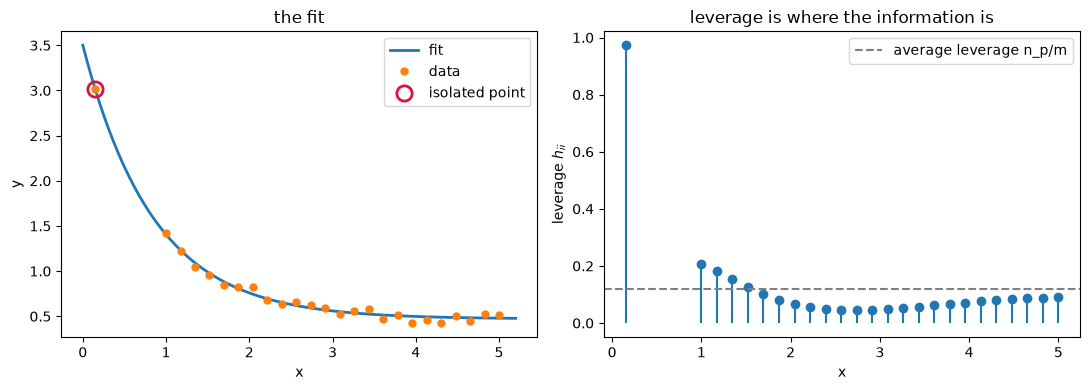

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
xf = np.linspace(0.0, 5.2, 300)
ax[0].plot(xf, model_np(xf, *res.popt), '-', lw=2, label='fit')
ax[0].plot(x, y, 'o', ms=5, label='data')
ax[0].plot(x[0], y[0], 'o', ms=11, mfc='none', mec='crimson', mew=2, label='isolated point')
ax[0].set_xlabel('x'); ax[0].set_ylabel('y'); ax[0].legend(); ax[0].set_title('the fit')

ax[1].stem(x, lev, basefmt=' ')
ax[1].axhline(J.shape[1] / x.size, ls='--', c='gray', label='average leverage n_p/m')
ax[1].set_xlabel('x'); ax[1].set_ylabel('leverage $h_{ii}$')
ax[1].legend(); ax[1].set_title('leverage is where the information is')
plt.tight_layout()

One point carries leverage far above the $n_p/m$ average while its residual is
utterly ordinary. Residual plots — the reflex for finding problem points —
cannot see it, because leverage and residual are different questions. A
high-leverage point is not an error; it is a point the fit *depends on*, which
is worth knowing whether or not it is also wrong.

## 3. Does the linearization tell the truth?

`dpopt_ddata` is a derivative: it predicts the effect of an *infinitesimal*
nudge. The question practitioners actually ask — "what if I drop this point?" —
is a finite change. Classical regression bridges the two with

$$\hat{p}_{(i)} - \hat{p} = -\frac{\partial \hat{p}}{\partial y_i}
\cdot \frac{r_i}{1 - h_{ii}},$$

the **DFBETA**, where the $1/(1-h_{ii})$ factor accounts for the fit having
been pulled toward the point being removed. Nothing guarantees this holds for a
nonlinear model. So check it the only way that settles it: actually drop each
point and re-fit.

In [6]:
pred = -res.dpopt_ddata * (resid / (1.0 - lev))[None, :]     # (n_params, m) DFBETA

actual = np.zeros_like(pred)
for i in range(x.size):
    keep = np.ones(x.size, bool); keep[i] = False
    ri = pounce.curve_fit(model, x[keep], y[keep], p0=P0, options=OPT)
    actual[:, i] = ri.popt - res.popt

for j, nm in enumerate(res.param_names):
    num = np.abs(pred[j] - actual[j]).max()
    den = np.abs(actual[j]).max()
    print(f"  {nm}: max |predicted - actual| = {num:.2e}   "
          f"({100*num/den:.1f}% of the largest actual shift)")

  a: max |predicted - actual| = 1.78e-03   (0.7% of the largest actual shift)
  b: max |predicted - actual| = 3.06e-03   (4.4% of the largest actual shift)
  c: max |predicted - actual| = 1.02e-03   (11.8% of the largest actual shift)


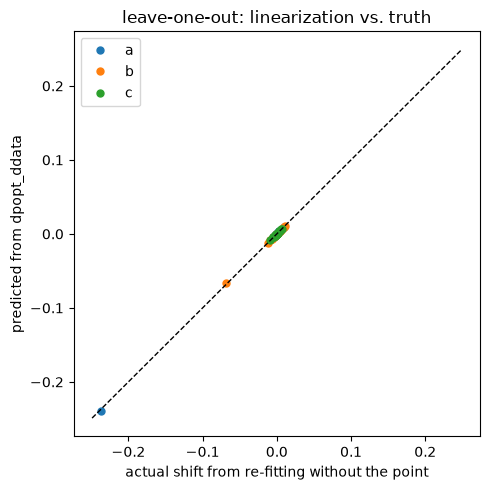

In [7]:
fig, ax = plt.subplots(figsize=(5, 5))
for j, nm in enumerate(res.param_names):
    ax.plot(actual[j], pred[j], 'o', ms=5, label=nm)
lim = 1.05 * np.abs(actual).max()
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=1)
ax.set_xlabel('actual shift from re-fitting without the point')
ax.set_ylabel('predicted from dpopt_ddata')
ax.set_title('leave-one-out: linearization vs. truth')
ax.legend(); plt.tight_layout()

The linearization tracks the re-fits closely, and it did so with **one
factorization** instead of $m$ fits. Where it is off, the gap is the neglected
residual curvature: `curve_fit` builds `dpopt_ddata` from the **Gauss-Newton**
Hessian, the same one behind `pcov`, so the influence is a first-order
quantity. Treat it as a ranking of points that is cheap and reliable, and
re-solve when a specific number has to be exact.

## 4. Cook's distance: one number per point

Leverage says how much the fit *listens* to a point; the residual says how much
the point *disagrees*. Cook's distance multiplies the two into the thing you
usually want — how far the whole parameter vector moves if the point leaves,
measured in the fit's own covariance metric.

In [8]:
Pinv = np.linalg.pinv(res.pcov)
cook = np.einsum('ji,jk,ki->i', pred, Pinv, pred) / len(res.popt)        # from influence
cook_true = np.einsum('ji,jk,ki->i', actual, Pinv, actual) / len(res.popt)   # from re-fits
order = np.argsort(cook)[::-1]
print(f"Cook's D from influence vs from re-fits: rank correlation "
      f"{np.corrcoef(np.argsort(np.argsort(cook)), np.argsort(np.argsort(cook_true)))[0,1]:.4f}, "
      f"same top-3: {set(order[:3]) == set(np.argsort(cook_true)[::-1][:3])}\n")

print(f"{'rank':>4} {'x':>7} {'leverage':>9} {'|resid|':>9} {'Cook D':>10}")
for r_, i in enumerate(order[:5], 1):
    print(f"{r_:>4} {x[i]:>7.2f} {lev[i]:>9.4f} {abs(resid[i]):>9.4f} {cook[i]:>10.4f}")

big_r = int(np.abs(resid).argmax())
print(f"\nlargest-residual point is x={x[big_r]:.2f}, Cook rank "
      f"{list(order).index(big_r)+1} of {x.size}")
print(f"most influential point is  x={x[order[0]]:.2f}, residual rank "
      f"{list(np.argsort(np.abs(resid))[::-1]).index(order[0])+1} of {x.size}")

Cook's D from influence vs from re-fits: rank correlation 0.9992, same top-3: True

rank       x  leverage   |resid|     Cook D
   1    0.15    0.9730    0.0051     6.9388
   2    2.04    0.0665    0.0809     0.1011
   3    4.30    0.0797    0.0647     0.0797
   4    3.96    0.0716    0.0685     0.0789
   5    1.35    0.1533    0.0406     0.0712

largest-residual point is x=2.04, Cook rank 2 of 25
most influential point is  x=0.15, residual rank 24 of 25


The two rankings disagree, which is the entire reason the influence matrix is
worth computing. Sorting by residual finds points that fit badly. Sorting by
influence finds points the answer *rests on* — and those are the ones whose
measurement you would want to repeat.

## 5. A parameter at a bound has no influence at all

Now the case the textbook formula gets wrong in kind, not degree.

Bound the offset $c \in [1, 2]$ when the data prefer $c \approx 0.5$. The fit
lands with $c$ pinned at 1.0. A pinned parameter **cannot move**: perturb any
$y_i$ by any small amount and $c$ stays exactly where the bound holds it. Its
influence is identically zero, and the effective degrees of freedom drop from 3
to 2, because the data are no longer determining $c$.

`pinv(J)` knows none of this — it has never heard of the bound.

In [9]:
KW_B = dict(bounds=[(0, np.inf), (None, None), (1.0, 2.0)])
rb = pounce.curve_fit(model, x, y, p0=P0, sensitivity=True, options=OPT, **KW_B)
Jb = jac_at(rb.popt, x)

print("popt        :", np.round(rb.popt, 5))
print("active_mask :", [bool(v) for v in rb.active_mask], " cov_source:", rb.cov_source)
print()
print("influence row for the pinned parameter c :",
      f"max |.| = {np.abs(rb.dpopt_ddata[2]).max():.3e}   (exactly zero)")
print("what pinv(J) would have reported for c   :",
      f"max |.| = {np.abs(np.linalg.pinv(Jb)[2]).max():.3e}")
print()
print(f"trace(H) = {np.trace(Jb @ rb.dpopt_ddata):.8f}   "
      f"(3 parameters - 1 active bound = 2 effective)")

popt        : [3.03234 2.67695 1.     ]
active_mask : [False, False, True]  cov_source: reduced_hessian(projected)

influence row for the pinned parameter c : max |.| = 0.000e+00   (exactly zero)
what pinv(J) would have reported for c   : max |.| = 5.516e-02

trace(H) = 2.00000000   (3 parameters - 1 active bound = 2 effective)


In [10]:
# ground truth: perturb one datum, re-solve, difference
def refit_influence(fit_kw, i, h=1e-4):
    yp = y.copy(); yp[i] += h
    ym = y.copy(); ym[i] -= h
    fp = pounce.curve_fit(model, x, yp, p0=P0, options=OPT, **fit_kw)
    fm = pounce.curve_fit(model, x, ym, p0=P0, options=OPT, **fit_kw)
    return (fp.popt - fm.popt) / (2 * h)

def show(tag, fit_kw, M_new, M_old, idx):
    row = lambda v: "".join(f"{t:>11.5f}" for t in v)
    print(f"{'x':>6}  {'':<24}{'a':>11}{'b':>11}{'c':>11}")
    for i in idx:
        truth = refit_influence(fit_kw, i)
        print(f"{x[i]:>6.2f}  {'dpopt_ddata':<24}" + row(M_new[:, i]))
        print(f"{'':>6}  {'re-solve (truth)':<24}" + row(truth))
        print(f"{'':>6}  {'pinv(J), the old answer':<24}" + row(M_old[:, i]))

show('bound', KW_B, rb.dpopt_ddata, np.linalg.pinv(Jb), (0, 12))

# the robust version of the claim: sign agreement with the truth over every point
truth_b = np.column_stack([refit_influence(KW_B, i) for i in range(x.size)])
free = [0, 1]
agree = lambda M: np.mean(np.sign(M[free]) == np.sign(truth_b[free]))
print(f"\nsign agreement with the re-solve, over the {len(free)}x{x.size} free-parameter entries")
print(f"   dpopt_ddata : {100*agree(rb.dpopt_ddata):5.1f}%")
print(f"   pinv(J)     : {100*agree(np.linalg.pinv(Jb)):5.1f}%")

     x                                    a          b          c


  0.15  dpopt_ddata                 1.71794    0.49400    0.00000
        re-solve (truth)            1.61227    0.28470    0.00000
        pinv(J), the old answer     1.72379    0.51401    0.00227


  2.91  dpopt_ddata                -0.02457   -0.05045    0.00000
        re-solve (truth)           -0.01378   -0.02907    0.00000
        pinv(J), the old answer     0.11333    0.42112    0.05346



sign agreement with the re-solve, over the 2x25 free-parameter entries
   dpopt_ddata :  96.0%
   pinv(J)     :  34.0%


The pinned row is zero, matching the re-solve exactly. `pinv(J)` reports a
confident nonzero influence for a parameter that is welded in place, and on the
free parameters it disagrees with the truth in **sign** on most points, because
it is answering a question about a different, unconstrained fit. That is
[#922](https://github.com/jkitchin/pounce/issues/922): before the fix,
`dpopt_ddata` returned exactly the `pinv(J)` row above.

Note that the projected answer is right in structure and direction but not to
the last digit — at $x = 0.15$, the extreme-leverage point, the $b$ component
sits well off the re-solve. That gap is the Gauss-Newton linearization from
section 3, now being asked to work at a point where the fit is most curved. The
projection is what fixed the *kind* of error; the magnitude is still
first-order.

## 6. Influence lives in the constraint's null space

The sharper version. Tie two parameters with $a + c \le K$ and choose $K$ so it
binds. Then $a + c = K$ holds *no matter what the data say*, so any admissible
data perturbation must satisfy

$$\frac{\partial a}{\partial y_i} + \frac{\partial c}{\partial y_i} = 0$$

for every point $i$ — the influence vector lies in the null space of the active
constraint. This is not an approximation to check; it is a structural identity
that any correct answer satisfies exactly.

In [11]:
K = 2.6
KW_C = dict(constraints=[{'type': 'ineq', 'fun': lambda p: K - (p[0] + p[2])}])
rc = pounce.curve_fit(model, x, y, p0=P0, sensitivity=True, options=OPT, **KW_C)
Jc = jac_at(rc.popt, x)

print(f"a + c = {rc.popt[0] + rc.popt[2]:.10f}   (K = {K}, constraint is active)")
print()
print("da/dy + dc/dy, over all points")
print(f"   dpopt_ddata : max |.| = {np.abs(rc.dpopt_ddata[0] + rc.dpopt_ddata[2]).max():.3e}")
pj = np.linalg.pinv(Jc)
print(f"   pinv(J)     : max |.| = {np.abs(pj[0] + pj[2]).max():.3e}")
print()
print(f"trace(H) = {np.trace(Jc @ rc.dpopt_ddata):.8f}   "
      f"(3 parameters - 1 active constraint = 2 effective)")

a + c = 2.6000000100   (K = 2.6, constraint is active)

da/dy + dc/dy, over all points
   dpopt_ddata : max |.| = 3.297e-12
   pinv(J)     : max |.| = 1.187e+00

trace(H) = 2.00000000   (3 parameters - 1 active constraint = 2 effective)


In [12]:
show('constraint', KW_C, rc.dpopt_ddata, pj, (0, 12))

     x                                    a          b          c
  0.15  dpopt_ddata                 0.03903   -0.07695   -0.03903
        re-solve (truth)            0.03479   -0.06975   -0.03479
        pinv(J), the old answer     1.07884    0.43831    0.10858


  2.91  dpopt_ddata                -0.04618   -0.00502    0.04618
        re-solve (truth)           -0.04645   -0.00455    0.04645
        pinv(J), the old answer    -0.10035   -0.03187    0.03848


The influence now moves $a$ and $c$ in exact opposition, as the binding
constraint requires, and matches the re-solve. `pinv(J)` moves them the *same*
direction — a perturbation that walks straight off the feasible set, describing
a fit that was never solved.

This is the failure mode worth internalizing. The old number was not noisy or
slightly stale; it was self-consistent, plausible, dimensionally correct, and
describing a different problem. Nothing about it looked wrong.

## 7. What it costs

The influence matrix is $m$ columns, each a back-solve against a factorization
that already exists. The alternative — re-fitting without each point — is $m$
optimizations.

In [13]:
t0 = time.perf_counter()
for _ in range(5):
    pounce.curve_fit(model, x, y, p0=P0, sensitivity=True, options=OPT)
t_sens = (time.perf_counter() - t0) / 5

t0 = time.perf_counter()
for _ in range(5):
    pounce.curve_fit(model, x, y, p0=P0, options=OPT)
t_fit = (time.perf_counter() - t0) / 5

t0 = time.perf_counter()
for i in range(x.size):
    keep = np.ones(x.size, bool); keep[i] = False
    pounce.curve_fit(model, x[keep], y[keep], p0=P0, options=OPT)
t_loo = time.perf_counter() - t0

print(f"plain fit                       : {1e3*t_fit:8.2f} ms")
print(f"fit + full influence matrix     : {1e3*t_sens:8.2f} ms  "
      f"({t_sens/t_fit:.2f}x the plain fit)")
print(f"{x.size} leave-one-out re-fits         : {1e3*t_loo:8.2f} ms  "
      f"({t_loo/t_sens:.1f}x the influence matrix)")

plain fit                       :    34.61 ms
fit + full influence matrix     :    34.91 ms  (1.01x the plain fit)
25 leave-one-out re-fits         :   854.56 ms  (24.5x the influence matrix)


The gap grows with the size of the dataset, since the re-fit route costs one
full solve per point while the factorization is paid for once. That is the same
accounting as the parametric sensitivity elsewhere in POUNCE: the expensive
object was already built, and the derivative is a back-solve against it.

## 8. Influence on a decision, not on a parameter

Parameters are rarely the deliverable. Suppose the fit is used to pick an
operating point — the $x$ at which the response first drops below a threshold
$y^{\star}$:

$$x^{\star}(p) = -\frac{1}{b} \ln\left(\frac{y^{\star} - c}{a}\right).$$

The chain rule carries influence straight through:
$\partial x^{\star}/\partial y_i = (\partial x^{\star}/\partial p)
\cdot (\partial p / \partial y_i)$. That composite is the number a decision
actually rests on, and it need not rank the points the way leverage does.

In [14]:
YSTAR = 1.2
a_, b_, c_ = res.popt
xstar = -np.log((YSTAR - c_) / a_) / b_
dxs_dp = np.array([
    1.0 / (a_ * b_),                                  # d/da
    np.log((YSTAR - c_) / a_) / b_**2,                # d/db
    1.0 / (b_ * (YSTAR - c_)),                        # d/dc
])
infl_dec = dxs_dp @ res.dpopt_ddata                   # (m,) influence on x*

print(f"x* = {xstar:.4f}  (response crosses y* = {YSTAR})")
top_dec = np.argsort(np.abs(infl_dec))[::-1][:3]
top_lev = np.argsort(lev)[::-1][:3]
print("top 3 points by influence on the decision :", np.round(x[top_dec], 2))
print("top 3 points by leverage                  :", np.round(x[top_lev], 2))

# spot-check the composite against a re-solve
i = int(top_dec[0]); h = 1e-4
yp = y.copy(); yp[i] += h
rp = pounce.curve_fit(model, x, yp, p0=P0, options=OPT)
ap, bp, cp = rp.popt
xs_p = -np.log((YSTAR - cp) / ap) / bp
print(f"\nd x*/d y[{i}] : predicted {infl_dec[i]:+.5f}   re-solve {(xs_p - xstar)/h:+.5f}")

x* = 1.2106  (response crosses y* = 1.2)
top 3 points by influence on the decision : [1.   1.17 1.35]
top 3 points by leverage                  : [0.15 1.   1.17]

d x*/d y[1] : predicted +0.21876   re-solve +0.22132


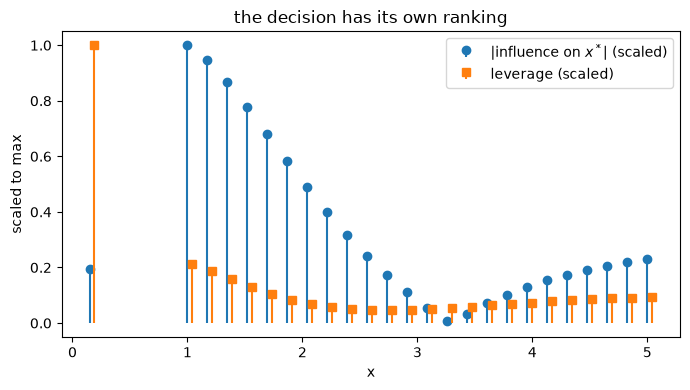

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.stem(x, np.abs(infl_dec) / np.abs(infl_dec).max(), basefmt=' ',
        linefmt='C0-', markerfmt='C0o', label='|influence on $x^*$| (scaled)')
ax.stem(x + 0.04, lev / lev.max(), basefmt=' ',
        linefmt='C1-', markerfmt='C1s', label='leverage (scaled)')
ax.set_xlabel('x'); ax.set_ylabel('scaled to max')
ax.set_title('the decision has its own ranking')
ax.legend(); plt.tight_layout()

## What to take away

- **The influence matrix generalizes the hat matrix.** `J @ res.dpopt_ddata` is
  the hat matrix whenever the textbook has one, and remains meaningful when it
  does not. Its diagonal is leverage; its trace is the effective degrees of
  freedom.
- **Leverage and residual are different questions.** The most influential point
  in this notebook has an unremarkable residual, and the largest residual
  belongs to a point that barely matters. A residual plot cannot find the first
  one.
- **The classical formula is inadmissible once anything binds.** A parameter at
  a bound has exactly zero influence, and under an active constraint the
  influence lies in that constraint's null space. `pinv(J)` violates both,
  silently, while looking entirely reasonable — which is why
  [#922](https://github.com/jkitchin/pounce/issues/922) survived from the
  feature's first commit: the only test that asked for `dpopt_ddata` asked on
  an unconstrained fit, and asserted equality with `pinv(J)`.
- **It is a linearization, and says so.** Built from the Gauss-Newton Hessian,
  it ranks points cheaply and reliably; when an exact number matters, re-solve.
- **Cheap because the factorization already exists** — one back-solve per
  point, against a matrix the solve had to build anyway.

Related: [`22_curve_fit.ipynb`](22_curve_fit.ipynb) for the fitting API,
[`40_shadow_prices_expire.ipynb`](40_shadow_prices_expire.ipynb) for how far a
first-order sensitivity can be trusted, and
[`43_sobolev_training.ipynb`](43_sobolev_training.ipynb) for the same
factorization answering a different question.